In [1]:
import sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import numpy as np  # package for arrays
import matplotlib.pyplot as plt  # package for plotting
from time import time 
import random as ran

In [2]:
def get_details(y):
    temps = set(y)
    temps = np.sort(np.array(list(temps)))
    np.sort([1,])
    Tcount = {}
    for kT in temps:
        Tcount[kT] = np.count_nonzero(y==kT)
    return Tcount

def order_data(y, X):
    indices = np.argsort(y)
    y = y[indices]
    X = X[indices]
    return (y, X)

def reconstruct_lattice(lattice):
    L = round(np.sqrt(len(lattice)))
    return np.reshape(lattice, (L,L))

def show_state(state):
    img = reconstruct_lattice(state)
    _, ax = plt.subplots()
    ax.imshow(img, cmap=plt.get_cmap('gray'), interpolation="nearest")

### Data

In [3]:
method = 'up_down'
L = 40
x = 1

path = 'data/'+method+'/L='+str(L)+'_x='+str(x)

X = np.loadtxt(path+'_X.txt') 
y = np.loadtxt(path+'_y.txt') 

y, X = order_data(y, X)

print(y.shape)
get_details(y)

(4920,)


{1.5: 180,
 1.6: 179,
 1.7: 193,
 1.8: 188,
 1.9: 163,
 2.0: 350,
 2.1: 356,
 2.2: 372,
 2.3: 358,
 2.4: 357,
 2.5: 379,
 2.6: 395,
 2.7: 368,
 2.8: 370,
 2.9: 354,
 3.0: 358}

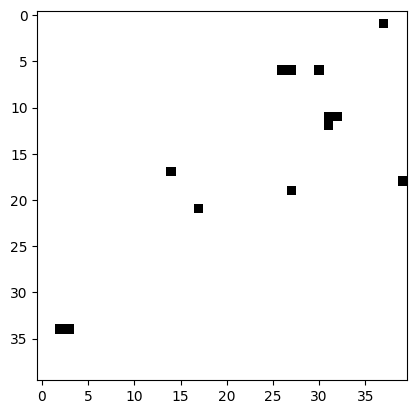

In [4]:
show_state(X[0])

### Mean absolute value + error bars

In [5]:
def mean_absolute(y, values, central_limit=True):
    temperatures = list(set(y))
    
    means = []
    errs = []
    for kT in temperatures:
        filt = y==kT
        samples = values[filt]
        N_samples = len(samples)
        
        samples = np.abs(samples)
        mean = np.mean(samples)
        if central_limit:
            err = np.std(samples)/np.sqrt(N_samples)
        else:
            err = np.std(samples)
        
        errs.append(err)
        means.append(mean)
        
    return temperatures, means, errs
    
def reorder(temperatures, values, errs='None'):
    temperatures = np.array(temperatures)
    values = np.array(values)
    errs = np.array(errs)
    
    indices = np.argsort(temperatures)
    
    if errs != 'None':
        return temperatures[indices], values[indices], errs[indices]
    
    return temperatures[indices], values[indices]

### Magnetisation


In [6]:
def magnetisation(state):
    N = np.count_nonzero(state)
    return np.sum(state)/N

def mags(states):
    m = []
    for state in states:
        m.append(magnetisation(state))
    return np.array(m)

def plot_m(X, y):
    m = mags(X)
    T, M, err = mean_absolute(y, m, central_limit=True)
    T, M, err = reorder(T, M, err)
    
    plt.errorbar(T, M, yerr=err, fmt='.', ecolor='red')

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_63344/842564004.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


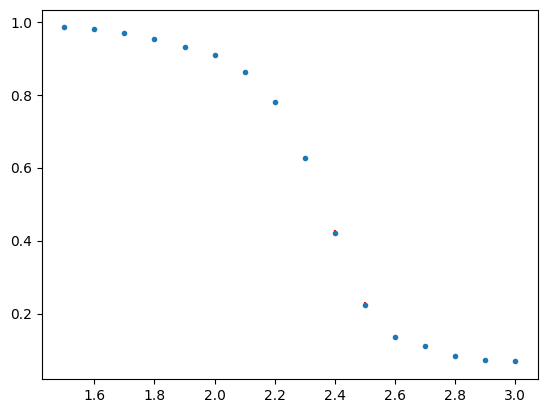

In [7]:
plot_m(X, y)

### Specific Heat (it is NOT the same as magnetic susceptibility)

$$ C_v = \sigma_E^2/T^2 $$

where $\sigma_E$ is the std of the energy

Note: we are setting k=1 and J=1

In [8]:
def energy(state):
    # reconstruct shape
    N = len(state)
    L = round(np.sqrt(N))
    state = np.reshape(state, (L,L))
    
    J = 1 # this is what it is for everything
    
    E = 0
    for i,row in enumerate(state):
        for j,spin in enumerate(row):
            
            
            NNa = state[(i-1, j)] # Nearest neighbor above
            NNl = state[(i, j-1)] # Nearest neighbor left
            if i == L-1:
                NNb = state[(0, j)]
            else:
                NNb = state[(i+1, j)]
            if j == L-1:
                NNr = state[(i, 0)]
            else:
                NNr = state[(i, j+1)]
            
            E -= J*spin*(NNb + NNa + NNl + NNr)
    
    return E/2 # we counted each connection twice so we need to divide the energy by 2

def energies(X):
    H = []
    for state in X:
        H.append(energy(state))
    return np.array(H)

def specific_heat(y, energies):
    temperatures = list(set(y))
    
    Cv = []
    for T in temperatures:
        filt = y==T
        energies_ = energies[filt]
        sigma = np.std(energies_)
        Cv.append((sigma/T)**2)
        
    return Cv

def plot_Cv(y, X):
    H = energies(X)
    Cv = specific_heat(y, H)
    T = list(set(y))
    
    plt.scatter(T, Cv)

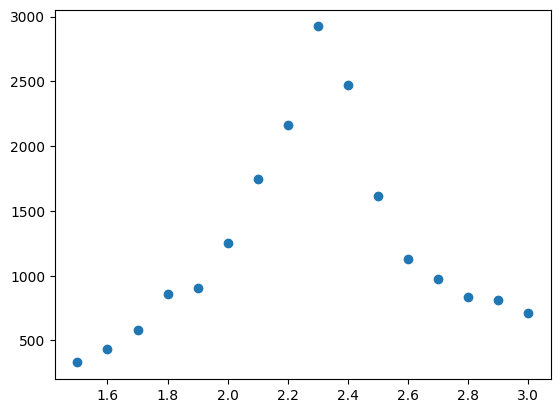

In [9]:
plot_Cv(y, X)

### Binder ratios

$$ Q = \frac{<m^2>}{<|m|>^2} $$

In [10]:
def binder(values, y, p=1):
    temperatures = list(set(y))
    squares = values**(2*p)
    absolutes = np.abs(values)**p # aboslutes to the power of p
    
    Q = []
    for kT in temperatures:
        filt = y==kT
        squares_ = squares[filt]
        absolutes_ = absolutes[filt]
        
        q = np.mean(squares_)/(np.mean(absolutes_)**2)
        Q.append(q)
    
    return Q 

def plot_binder(y, X):
    T = list(set(y))
    m = mags(X)
    Q = binder(m, y)
    T, Q = reorder(T, Q)
    plt.plot(T, Q)

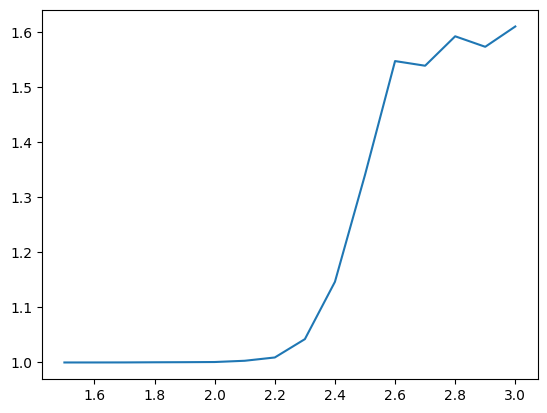

In [11]:
plot_binder(y, X)

# PCA

In [12]:
t1 = time()
reduced_data = PCA(n_components=2).fit_transform(X)
print(time()-t1)
reduced_data.shape

0.15075397491455078


(4920, 2)

In [13]:
p1 = reduced_data[:, 0]
p2 = reduced_data[:, 1]

### Analogy to magnetisation and magnetic susceptibility

In [14]:
temperatures, p1_mean, err1 = mean_absolute(y, p1)
temperatures, p2_mean, err2 = mean_absolute(y, p2)

Text(0.5, 1.0, '<|p2|> vs T')

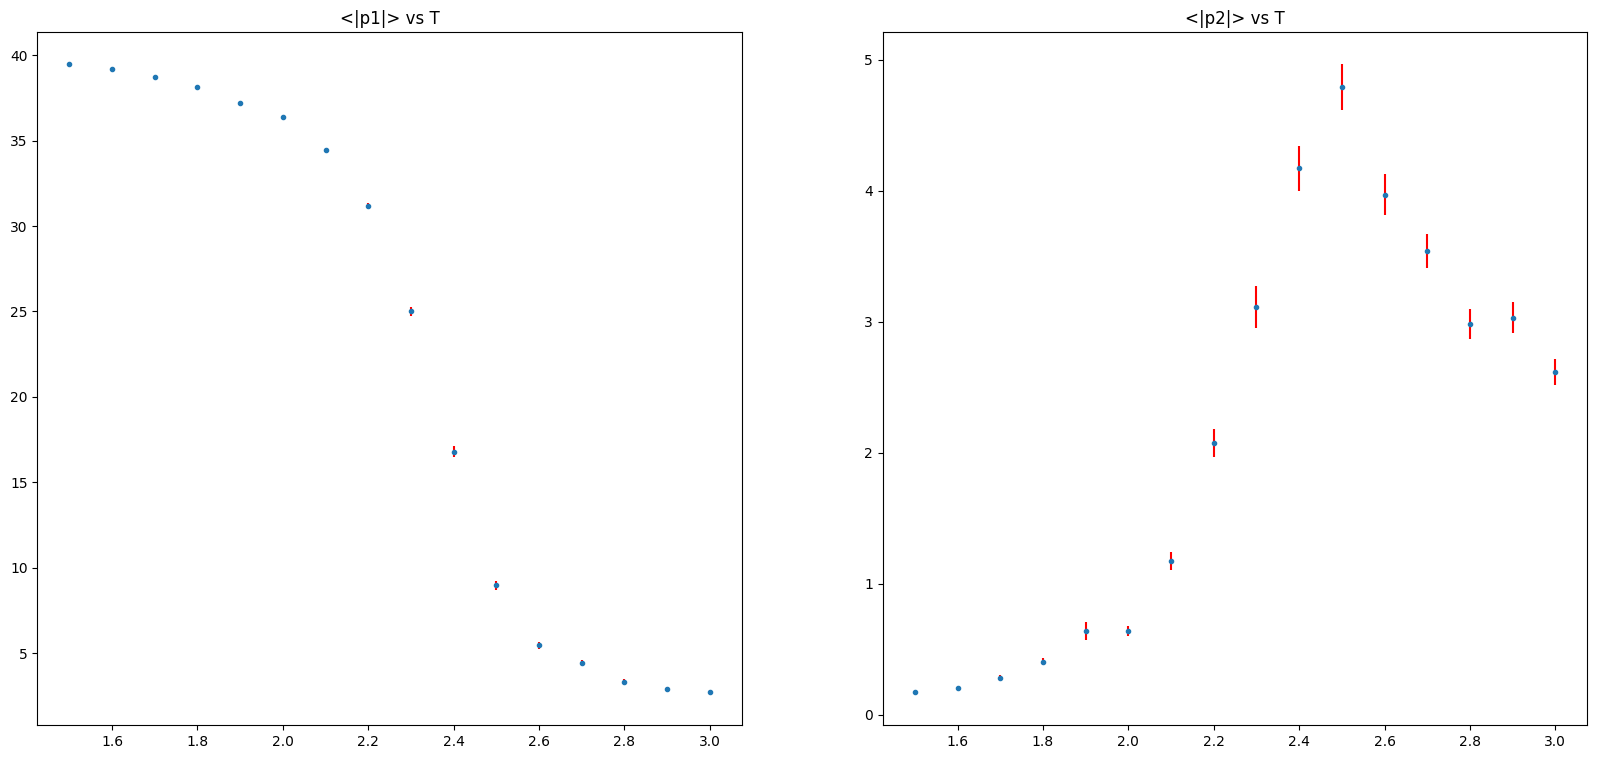

In [15]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,9))

# axs[0].scatter(temperatures, p1_mean)
axs[0].errorbar(temperatures, p1_mean, yerr=err1, fmt='.', ecolor='red')
axs[0].set_title('<|p1|> vs T')

axs[1].errorbar(temperatures, p2_mean, yerr=err2, fmt='.', ecolor='red')
axs[1].set_title('<|p2|> vs T')


Text(0.5, 0, 'p1')

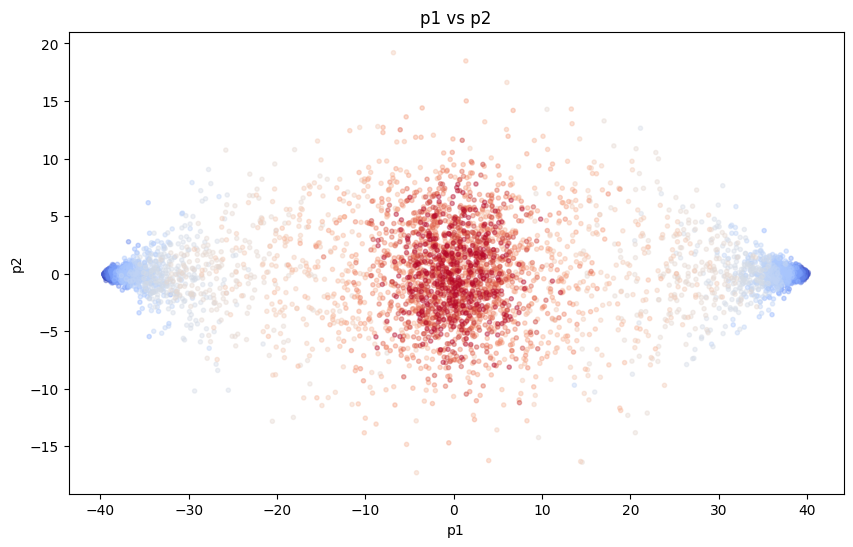

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(p1, p2, c=y, cmap='coolwarm', alpha=0.4, marker='.')
ax.set_title('p1 vs p2')
ax.set_ylabel('p2')
ax.set_xlabel('p1')

# fig.colorbar(cm.ScalarMappable(norm=None, cmap='coolwarm'), ax=ax)

## Plots of above and below Tc

## Plotting every temperature

### Clustering with KMeans

In [17]:
kmeans = KMeans(init="k-means++", n_clusters=3, n_init=4)
kmeans.fit(reduced_data)

KMeans(n_clusters=3, n_init=4)

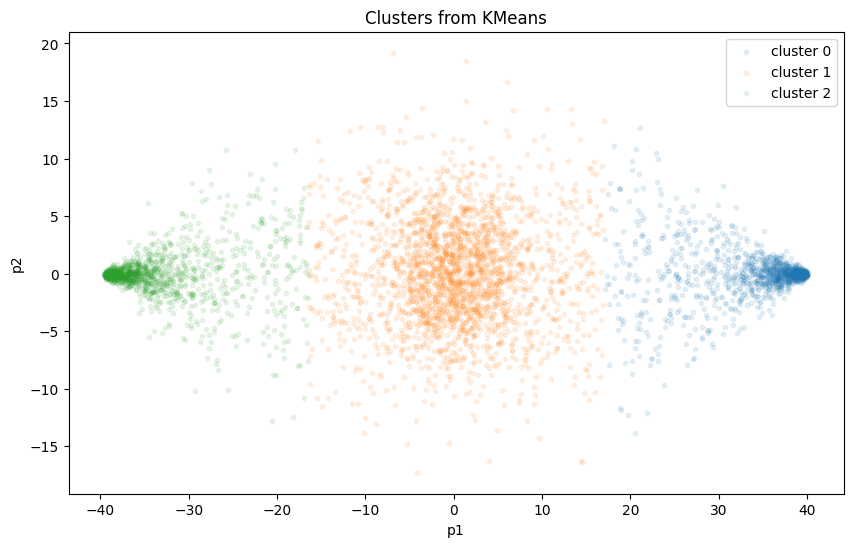

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

cluster0 = reduced_data[kmeans.labels_ == 0]
cluster1 = reduced_data[kmeans.labels_ == 1]
cluster2 = reduced_data[kmeans.labels_ == 2]

ax.scatter(cluster0[:, 0], cluster0[:, 1], alpha=0.1, marker='.', label='cluster 0')
ax.scatter(cluster1[:, 0], cluster1[:, 1], alpha=0.1, marker='.', label='cluster 1')
ax.scatter(cluster2[:, 0], cluster2[:, 1], alpha=0.1, marker='.', label='cluster 2')

ax.set_title('Clusters from KMeans')
ax.set_ylabel('p2')
ax.set_xlabel('p1')
ax.legend()

### Tc from clustered temperatures 

###### Alg 1: Tc to maximise preportion of 'above' labels above and 'below' labels below

Tc is the expectation value of the temperature w.r.t the weight

The weight is the proportion of 

In [19]:
labels = kmeans.labels_
y = y # should already be in order ascending order

n_ordered = np.count_nonzero(labels)
n_disordered = len(y) - n_ordered

def weight(labels, index):
    O_B = np.count_nonzero(labels[:index])
    O_A = np.count_nonzero(labels[index:])
    D_B = len(labels[:index]) - O_B
    D_A = len(labels[index:]) - O_A
    
    if O_B+O_A+D_B+D_A != len(labels):
        raise ValueError('somethings wrong brev')
        
    return O_B/(O_A + O_B) + D_A/(D_A + D_B)

weights = np.array([weight(labels, i) for i in range(len(y))])

expected_Tc = np.sum(weights*y)/np.sum(weights)
print(expected_Tc)

2.3446834888963433


##### Alg 2: Using the overlap 

1. Find the highest Tbelow and lowest Tabove. 
2. If Tbelow >= Tabove then calculate the midpoint and record as an estimate of Tc.
3. Throw these readings away and the next highest Tbelow and next lowest Tabove.
4. Repeat until the highest Tbelow < highest Tabove

In [33]:
filt0 = labels==1
filt1 = labels==0
filt2 = labels==2

Tabove = y[filt0]
Tbelow = np.concatenate((y[filt1], y[filt2]))

Tabove = np.sort(Tabove)
Tbelow = np.sort(Tbelow)

# overlap_T = set(Tabove).intersection(set(Tbelow))

criticals = []
highest_below = 9999
lowest_above = -9999
i = 0
while highest_below >= lowest_above:
    lowest_above = Tabove[i]  
    highest_below = Tbelow[-(i+1)]
    if highest_below >= lowest_above:
        criticals.append((highest_below+lowest_above)/2)
    i += 1

criticals = np.array(criticals)
Tc = np.mean(criticals)
err = np.std(criticals)

Tc

2.4014778325123145

In [31]:
Tabove[-1]

3.0

### DBSCAN for bad data (method_2 data)